Zadanie 2

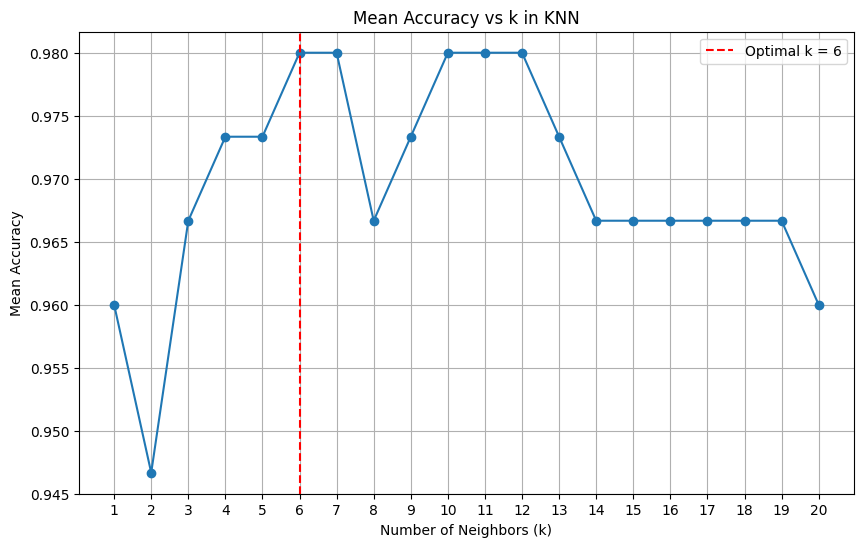

Optimal k: 6 with mean accuracy: 0.9800


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score 
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()
X = iris.data
y = iris.target
k_values = range(1, 21)

mean_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5)
    mean_accuracies.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(k_values, mean_accuracies, marker='o')
plt.title('Mean Accuracy vs k in KNN')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Accuracy')
plt.xticks(k_values)
plt.grid()

optimal_k = k_values[np.argmax(mean_accuracies)]
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.legend()
plt.show()
print(f'Optimal k: {optimal_k} with mean accuracy: {max(mean_accuracies):.4f}')

Zadanie 6

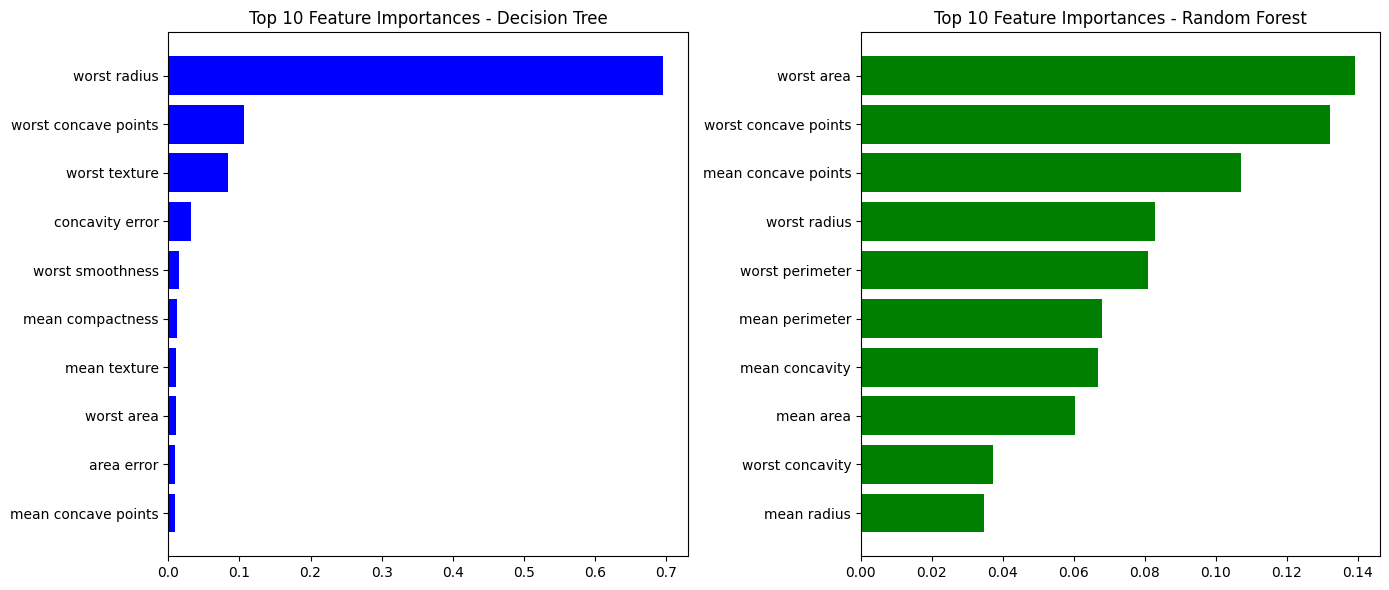

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier

breast_cancer = load_breast_cancer()
X_bc = breast_cancer.data
y_bc = breast_cancer.target

dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_bc, y_bc)

rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_bc, y_bc)

dt_importances = dt_classifier.feature_importances_
rf_importances = rf_classifier.feature_importances_

feature_names = breast_cancer.feature_names

dt_top_indices = np.argsort(dt_importances)[-10:][::-1]
rf_top_indices = np.argsort(rf_importances)[-10:][::-1]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.barh(range(10), dt_importances[dt_top_indices][::-1], color='blue')
plt.yticks(range(10), feature_names[dt_top_indices][::-1])
plt.title('Top 10 Feature Importances - Decision Tree')

plt.subplot(1, 2, 2)
plt.barh(range(10), rf_importances[rf_top_indices][::-1], color='green')
plt.yticks(range(10), feature_names[rf_top_indices][::-1])
plt.title('Top 10 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

    

Opis różnic:  
1. Decision Tree może skupić się na jednej lub kilku cechach, które są najbardziej informacyjne, podczas gdy Random Forest, będąc zespołem wielu drzew, może rozłożyć wagę na więcej cech, co często prowadzi do bardziej stabilnych i generalizujących modeli.
2. W przypadku Decision Tree, jedna cecha może dominować, co może prowadzić do nadmiernego dopasowania, podczas gdy Random Forest może lepiej radzić sobie z szumem i korelacjami między cechami, co często skutkuje bardziej zrównoważonym rozkładem ważności cech.    



Zadanie 8

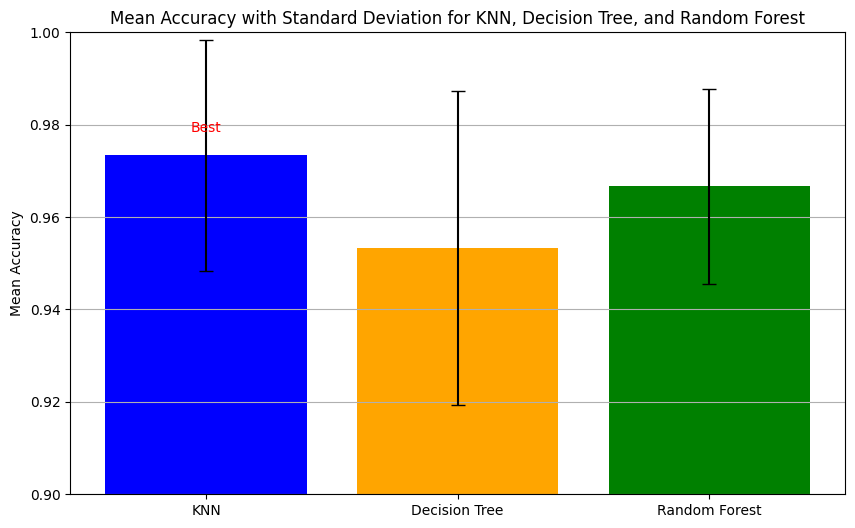

Best Algorithm: KNN with mean accuracy: 0.9733 and std: 0.0249


In [4]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

knn_classifier = KNeighborsClassifier(n_neighbors=5)
dt_classifier = DecisionTreeClassifier(random_state=42)
rf_classifier = RandomForestClassifier(random_state=42) 

classifiers = [knn_classifier, dt_classifier, rf_classifier]
classifier_names = ['KNN', 'Decision Tree', 'Random Forest']

mean_accuracies = []
std_accuracies = [] 
for clf in classifiers:
    scores = cross_val_score(clf, X, y, cv=5)
    mean_accuracies.append(scores.mean())
    std_accuracies.append(scores.std())

plt.figure(figsize=(10, 6))
plt.bar(classifier_names, mean_accuracies, yerr=std_accuracies, capsize=5, color=['blue', 'orange', 'green'])
plt.title('Mean Accuracy with Standard Deviation for KNN, Decision Tree, and Random Forest')
plt.ylabel('Mean Accuracy')
plt.ylim(0.9, 1.0)
plt.grid(axis='y')

best_index = np.argmax(mean_accuracies)
plt.text(best_index, mean_accuracies[best_index] + 0.005, 'Best', ha='center', color='red')
plt.show()
print(f'Best Algorithm: {classifier_names[best_index]} with mean accuracy: {mean_accuracies[best_index]:.4f} and std: {std_accuracies[best_index]:.4f}')